Problem 1 

part a.)
I'll try to get the formula for how long you end up waiting.
This is sorta markov chain based. Every flip we have a 50% chance of resetting or a 50% chance of incrementing the count 1
We can find the expected length of the chain through a recursive equation. For example:
n=1 we have a 50% chance to flip a correct call, or a 50% chance to reset our streak. n_1 = .5(1+n_1) + .5
This represents either  the state failing and resetting to go again with more tries, or the state reaching n=1.
n_1 = 2
n_2 = .5(1+n_2) + .5^2(2+n_2) + .5^2(2)
Note: the stuff in parentheses is like the number of coin flips we have to do. If we fail the first one, we add a flip but we then still need to go until we get 2 flips. At best it takes 2 flips to get 2 correct calls
Here our states are either failing the first flip and resetting to try again, making the first flip but failing the second(where we reset by 2 since we've now used 2 coin flips). And then the chance we get it. 
n_2 = 1+.5/.5^2 = 3/2/1/4
n_2 = 6
n_3 = .5(1+n_3) + .5^2(2+n_2) + .5^3(3+n_3) + .5^3(3)
n_3 = 14
n_4 = .5(1+n_4) + .5^2(2+n_4) + .5^3(3+n_4) + .5^4(4+n_4) + .5^4(4)
n_4 = 30

hmm 2, 6, 14, 30. Let's use the sequence finder https://oeis.org/A000918
aaaaaand one of the comments on this specific one is about this problem so I think this is going to be correct
n_x = 2^x - 2
This however notes that for x heads you want to do x+1 as your power. 

If we solve for n_14 we find it is 2^15 - 2
n_14 = 32766

part b.) 

Winning 14 coin tosses by chance is a slightly different question. The odds of that are just 1/2^14. 

So we need to find the sigma value which gives us 1-1/2^14 the ratio of the Gaussian's area

I will use scipy.stats.norm.ppf, which is an inverse function for the cdf of a normal distribution
Some numerical approximation surely happening behind the scenes but works for me now

scipy.stats.norm.ppf(1-(1/(2\*\*14))) = 3.841930685501911

So it is a 3.84 sigma event, which is not our 5 sigma target.







I'll leave what I did earlier in as well since I am still a little confused how I got very close to the right answer using it lol.

We need to define our gaussian for 14 coin flips. The mean value should be 7, as with a fair coin we expect 50% heads

The variance is \<n>^2 - <n^2>. \<n> is just the expectation value which we know for a fair coin to be n/2, so 14/2=7

\<n^2> = integral from 0 to 14 of x^2 P(x) dx

This the like number of heads we get. So it works out to be 0\**2 * 1/2^14 + 1\**2 * 14/2^14 + 2\**2 * (2 choose 14)/2^14...

Wrote some code below to find this for me, I get \<n^2> = 52.5

Variance = 52.5-7**\2=3.5

standard deviation = sqrt(variance) = 1.8708 roughly


Now then we just find how many sigma 7 is from 14, and this is 7/sqrt(3.5) = 3.7417 sigma

Want to check the reasoning here since like we already know there are 14 flips? Idk feel like some of the wording here I 
need to clarify with Chris

In [43]:
from scipy.stats import norm
print(norm.ppf(1-(1/(2**14))))

3.841930685501911


In [12]:
import scipy
from scipy.special import comb
temp = 0
for i in range(0, 15):
    print(i, i**2 * (scipy.special.comb(14, i, exact = True)/(2**14)))
    temp += i**2 * (scipy.special.comb(14, i, exact = True)/(2**14))
print(temp)

0 0.0
1 0.0008544921875
2 0.022216796875
3 0.199951171875
4 0.9775390625
5 3.0548095703125
6 6.598388671875
7 10.26416015625
8 11.73046875
9 9.8975830078125
10 6.109619140625
11 2.688232421875
12 0.7998046875
13 0.1444091796875
14 0.011962890625
52.5


Problem 2

Part a.)
Show <ax+b> = a\<x>+b
<ax+b> = integral of x (ax+b) dx
<ax+b> = integral of x(ax) + x(b)
<ax+b> = integral of xax + integral of xb
<ax+b> = a\*integral of xx + \<b>
<ax+b> = a\<x> + b

Show Var(ax+b) = a^2 Var(x)
Var(ax+b) = <(ax+b)^2> - <ax+b>^2
Var(ax+b) = <a^2x^2 + 2abx + b^2> - <ax+b>^2 #we know <ax+b> = a\<x>+b
Var(ax+b) = <a^2x^2> + <2abx> + <b^2> - (a\<x> + b)^2
Var(ax+b) = a^2<x^2> + 2ab\<x> + b^2 - (a^2\<x>^2 + 2ab\<x> + b^2)
Var(ax+b) = a^2(<x^2> - \<x>^2)
Var(ax+b) = a^2 Var(x)

part b.)
Consider random variables x,y. Show Var(ax+y) = a^2Var(x) + Var(y) + 2aCov(x, y) = a^2Var(x) + Var(y) + 2aRhoSigma_xSigma_y
Cov(x, y) = <x-\<x> times y-\<y>> = \<xy>-\<x>\<y>

Var(ax+y) = <(ax+y)^2> - <ax+y>^2
...= <a^2x^2> + <2ayx> + <y^2> - <ax+b>^2
...= a^2<x^2> + <y^2> + 2a\<xy> - <ax+y>^2
...= a^2<x^2> + <y^2> + 2a\<xy> - (a^2\<x>^2 + \<y>^2 + 2a\<x>\<y>)
...= a^2(<x^2>-\<x>^2) + (<y^2>-\<y>^2) + (2a(\<xy>-\<x>\<y>))
Var(ax+y) = a^2Var(x) + Var(y) + 2aCov(x,y)

We let var (x) = σ2_x , var (y) = σ2_y , and ρ = Cov(x, y)/σ_xσ_y

Var(ax+y) = a^2(σ2_x) + σ2_y + 2aCov(x,y)
...=a^2(σ2_x) + σ2_y + 2aσ_xσ_yρ

part c.)
Use the fact Var(ax+y)>=0 and b.), show ρ must be in the domain \[-1, 1\] inclusive

First let's show that a = +/- σ_y/σ_x are the extremeum values of rho
Var(ax+y) = a^2(σ2_x) + σ2_y + 2aσ_xσ_yρ
Let Var(ax+y) = 0, which is the minimum possible value since Var(ax+y) >= 0
-2aσ_xσ_yρ = a^2(σ2_x) + σ2_y
ρ = (a^2(σ2_x) + σ2_y)/(-2aσ_xσ_y)
ρ = -aσ_x/2σ_y + -σ_y/(2aσ_x)

To find extremum, we take the derivitive. 
dρ/da = -σ_x/2σ_y + σ_y/2a^2σ_x
set dρ/da = 0
0 = -σ_x/2σ_y + σ_y/2a^2σ_x
a^2 = -σ_x/2σ_y + σ_y/2σ_x
a^2 = 1/2 (-σ_x/σ_y + σ_y/σ_x)
a = +/- sqrt(1/2(-σ_x/σ_y + σ_y/σ_x))


Problem 3

In [4]:
# Generate an array of 1000 random numbers from a chi2 distribution with 10 dof
chi2dist = np.random.chisquare(10,1000)

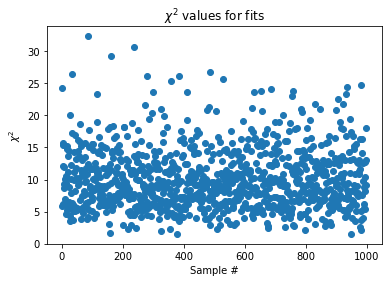

Text(0, 0.5, 'Number of Occourances')

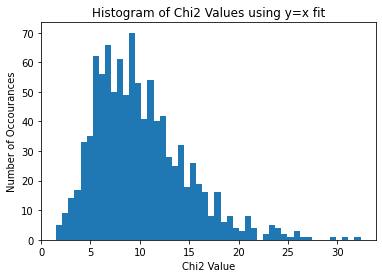

In [40]:
#Part a.)
#we just assume f(x) = x and calculate the chi^2 of that.

import numpy as np
import matplotlib.pyplot as plt

# 10 evenly spaced data points between 0.1 and 1
x = np.linspace(0.1, 1, 10)
temp=[]
for n in range(1000):
    # Randomly generate yi from y=x, varied by a Gaussian with sigma = 0.1
    yi = np.random.normal(x, 0.1)
    
    # Fit with a first-order polynomial (i.e. linear)
    fit = np.polyfit(x, yi, 1) 

    slope = fit[0]
    intercept = fit[1]
    chi2_fit = np.sum(
    ((yi - x) / 0.1)**2 #since we assume f(x) = x
    )
    temp.append(chi2_fit)
    
plt.scatter(range(1000), temp)    
plt.title(r'$\chi^2$ values for fits')
plt.ylabel(r'$\chi^2$')
plt.xlabel('Sample #')
plt.show()

plt.hist(temp, bins = 50)
plt.title('Histogram of Chi2 Values using y=x fit')
plt.xlabel('Chi2 Value')
plt.ylabel('Number of Occourances')
plt.show()
#This has 10 degrees of freedom. Degrees of freedom = # of data points - fit parameters
#and we have fixed the fit parameters. Slope = 1 and yint = 0 so these aren't free to move
#page 8 lecture 5

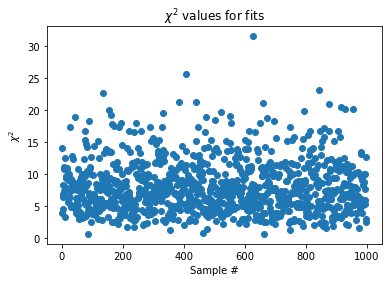

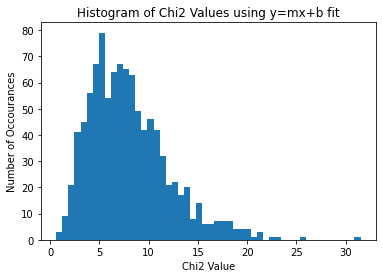

In [41]:
#Part b.)
#we allow slope and yint to be fit to. The code for this was already included in the example script

import numpy as np
import matplotlib.pyplot as plt

def Linear(x, slope, yint):
    return((slope*x) + yint)

# 10 evenly spaced data points between 0.1 and 1
x = np.linspace(0.1, 1, 10)
temp=[]
for n in range(1000):
    # Randomly generate yi from y=x, varied by a Gaussian with sigma = 0.1
    yi = np.random.normal(x, 0.1)
    
    # Fit with a first-order polynomial (i.e. linear)
    fit = np.polyfit(x, yi, 1) 

    slope = fit[0]
    intercept = fit[1]
    chi2_fit = np.sum(
    ((yi - Linear(x, slope, intercept)) / 0.1)**2 #since we assume f(x) = x
    )
    temp.append(chi2_fit)
    
plt.scatter(range(1000), temp)    
plt.title(r'$\chi^2$ values for fits')
plt.ylabel(r'$\chi^2$')
plt.xlabel('Sample #')
plt.show()

plt.hist(temp, bins = 50)
plt.title('Histogram of Chi2 Values using y=mx+b fit')
plt.xlabel('Chi2 Value')
plt.ylabel('Number of Occourances')
plt.show()

#This has 8 degrees of freedom. Degrees of freedom = # of data points - fit parameters
#10 data points and 2 free parameters

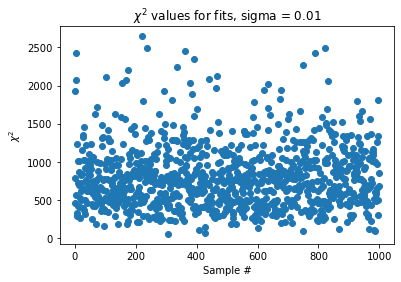

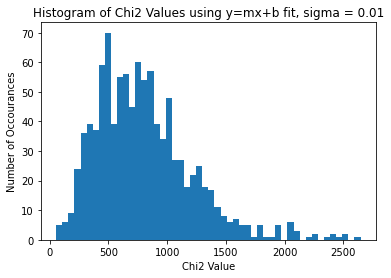

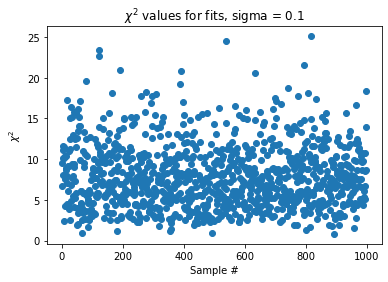

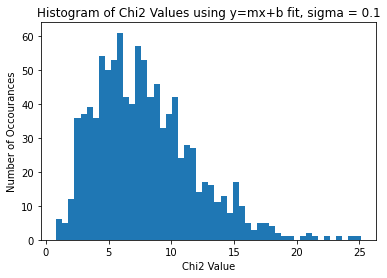

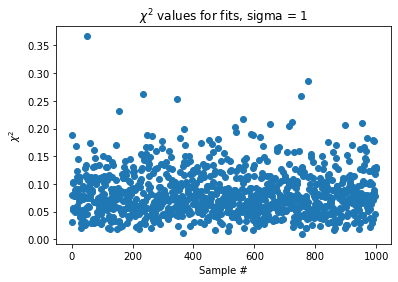

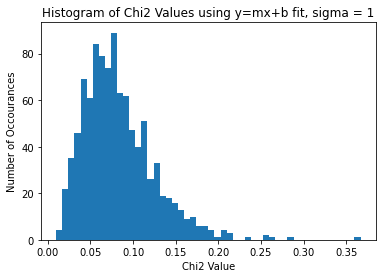

In [42]:
#Part c.) 
#lets change the assumed sigma within the chi2 calculation and show what happens
#I'll redo part b but change sigma to a really big and really small value

import numpy as np
import matplotlib.pyplot as plt

def Linear(x, slope, yint):
    return((slope*x) + yint)
sigma = [0.01, 0.1, 1]

for i in range(len(sigma)):
    # 10 evenly spaced data points between 0.1 and 1
    x = np.linspace(0.1, 1, 10)
    temp=[]
    for n in range(1000):
        # Randomly generate yi from y=x, varied by a Gaussian with sigma = 0.1
        yi = np.random.normal(x, 0.1)

        # Fit with a first-order polynomial (i.e. linear)
        fit = np.polyfit(x, yi, 1) 

        slope = fit[0]
        intercept = fit[1]
        chi2_fit = np.sum(
        ((yi - Linear(x, slope, intercept)) / sigma[i])**2 #since we assume f(x) = x
        )
        temp.append(chi2_fit)

    plt.scatter(range(1000), temp)    
    plt.title(r'$\chi^2$ values for fits, sigma = '+str(sigma[i]))
    plt.ylabel(r'$\chi^2$')
    plt.xlabel('Sample #')
    plt.show()

    plt.hist(temp, bins = 50)
    plt.title('Histogram of Chi2 Values using y=mx+b fit, sigma = '+str(sigma[i]))
    plt.xlabel('Chi2 Value')
    plt.ylabel('Number of Occourances')
    plt.show()
#super similar in looks but it's because matplotlib autoscales the yaxis.
#Low sigma = huge chi2, high sigma = way small chi2

In [33]:
2**15

32768